In [473]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path.cwd()

DATA_PATH = BASE_DIR / "atp_results.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Data file not found at {DATA_PATH}")

matches = pd.read_csv(DATA_PATH)

Section 1.1: Reorder participants alphabetically. Having participant1 always be the winner will make any model simply learn that participant1 is the winner and player strengths will be far less meaningful. 

In [476]:
#Reorder names so that p1 and p2 are in alphabetical order.
mask = matches['participant1_name'].str.casefold() > matches['participant2_name'].str.casefold()
p1 = [c for c in matches if c.startswith('participant1_')]
p2 = [c.replace('participant1_', 'participant2_') for c in p1]

matches.loc[mask, p1 + p2] = matches.loc[mask, p2 + p1].values
matches['is_participant1_winner'] = (~mask).astype(int)



1.2 Add home advantage column

In [479]:
# Add home_adv

matches['home_adv'] = matches['participant1_is_home'] - matches['participant2_is_home']

2.1 Analyse games per set factors (Surface, round)

Tournament rounds were not explicitly available in the dataset and were approximated using match ordering within each tournament-year. While this method captures the general progression of elimination tournaments, it may introduce classification error due to scheduling differences and overlapping rounds. This likely contributes to the slight non-monotonicity observed in the estimated round effects.

In [483]:
import numpy as np

matches['year'] = pd.to_datetime(matches['start_date']).dt.year

def assign_rounds(df):
    df = df.sort_values('start_date').copy()
    
    # Count matches per day
    match_counts = df.groupby('start_date').size()
    
    # Larger match count → earlier round
    day_rank = match_counts.rank(ascending=False, method='dense')
    
    day_to_round = dict(zip(match_counts.index, day_rank.astype(int)))
    
    df['round_num'] = df['start_date'].map(day_to_round)
    
    return df

matches = matches.groupby(['tournament_name', 'year'], group_keys=False).apply(assign_rounds)

/var/folders/68/trm783x14kd143qrp4tvsm040000gn/T/ipykernel_14548/2212598180.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  matches = matches.groupby(['tournament_name', 'year'], group_keys=False).apply(assign_rounds)


The data does not include the round of the match, so we will estimate the round

In [486]:
round_map = {
    0: 'Final',
    1: 'Semi-final',
    2: 'Quarter-final',
    3: 'Round of 16'
}

matches['round_label'] = matches['round_num'].map(round_map)
matches['round_label'] = matches['round_label'].fillna('Earlier Rounds')

matches['total_games'] = matches['participant1_games_won'] + matches['participant2_games_won']
matches['total_sets'] = matches['participant1_sets_won'] + matches['participant2_sets_won']
matches['games_per_set'] = matches['total_games'] / matches['total_sets']

We now investigate the impact of the surface and round on the number of games per set. 2.1 (i),(ii)

In [489]:
import statsmodels.formula.api as smf

model = smf.ols('games_per_set ~ C(surface) + C(round_label)', data=matches).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          games_per_set   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     67.15
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           1.69e-83
Time:                        10:15:29   Log-Likelihood:                -74518.
No. Observations:               41822   AIC:                         1.491e+05
Df Residuals:                   41815   BIC:                         1.491e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

Extending the analysis to a more granular classification of tournament rounds reveals a clear pattern of increasing competitiveness as tournaments progress. Relative to earlier rounds, matches in the Round of 16, quarter-finals, semi-finals, and finals all exhibit significantly more games per set, with coefficients ranging from +0.13 to +0.22 (p < 0.001). This suggests that later stage matches are more closely contested.

However, the effect is not perfectly monotonic, with Round of 16 matches showing slightly higher values than quarter-finals. This irregularity likely reflects noise introduced by the inferred round classification, as well as variation in tournament structures. Despite statistical significance, the magnitude of these effects remains small, and the overall explanatory power of the model is low (R² = 0.010). This indicates that the primary determinant of match competitiveness is likely player ability rather than tournament round.

2.2 Other factors for games per set: 
- The skill difference between the participants will affect the number of games per set. The more evenly matched pairs will have more games per set.
- Tournament factors such as number of sets (best of 3 or 5), and importance.

- Player styles interactions (defensive vs aggressive).
- External factors such as weather and home advantage, as well as the venue.

2.3 Trim to 10+ match players

In [494]:
from scipy.special import logit
# Combine both participant columns to count total matches per player
all_players = pd.concat([matches['participant1_name'], matches['participant2_name']])
counts = all_players.value_counts()

# Identify players with 10+ matches
frequent_players = counts[counts >= 10].index

# Keep only matches where BOTH players meet the criteria
matches_trimmed = matches[matches['participant1_name'].isin(frequent_players) & 
                matches['participant2_name'].isin(frequent_players)]

## encoding surface
surface_list = sorted(matches_trimmed['surface'].unique())
surface_to_idx = {s: i for i, s in enumerate(surface_list)}

num_surfaces = len(surface_list)
##

# Split to fit and val
fit_df = matches_trimmed[matches_trimmed['start_date'] < '2019-01-01'].copy()
val_df = matches_trimmed[
    (matches_trimmed['start_date'] >= '2019-01-01') &
    (matches_trimmed['start_date'] < '2020-01-01')
].copy()
test_df = matches_trimmed[matches_trimmed['start_date'] >= '2020-01-01'].copy()

fit_df['start_date'] = pd.to_datetime(fit_df['start_date'])
val_df['start_date'] = pd.to_datetime(val_df['start_date'])
test_df['start_date'] = pd.to_datetime(test_df['start_date'])

In [496]:
players_fit = sorted(list(set(fit_df['participant1_name']) | set(fit_df['participant2_name'])))
player_to_idx_fit = {p: i for i, p in enumerate(players_fit)}
num_players_fit = len(players_fit)

fit_df['p1_idx'] = fit_df['participant1_name'].map(player_to_idx_fit)
fit_df['p2_idx'] = fit_df['participant2_name'].map(player_to_idx_fit)


In [498]:
import numpy as np
from scipy.special import expit
sigmoid = expit


3.1 Model A identifiability and $\beta = 0$?: 
This model has an issue (What I would call a gauge freedom) where 
$(\alpha_i, \alpha_j) \rightarrow (\alpha_i + c, \alpha_j + c)$ has no effect on the prediction of the model. We fix this issue
in the fitting proceadure by fixing one of the alphas to zero.

As for the issue of $\beta$, in model A we set it to zero as to not accidentally overfit our model. 
When we want to include a home advantage this will be useful, but including a non-zero $\beta$ in this model will just include uneccesary noise. One key assumption of model A is that $p^{match}$ only depends on the two player strengths, therefore if two players have the same strength rating, our belief should be that they are both equaly likely to win.



Here we specify the details of model A and optimise the strength parameters with maximum likelihood estimation. In the interest of performance we include 
- A regulator $\lambda$ which controlls the level of L2 regularisation and penalises the optimisation against very large values of $\alpha$
- A time decay $\gamma$ relative to the date 2020-01-01, where the forecasting will begin later. This ensures that the values of $\alpha$ used when predicting outcomes arent overly influenced by very old matches.
- An updating rule: When we get to forecasting we will update our belief of a players strength based on the outcome of their matches in the same way as we would an Elo system. This updating rule based on the difference between the players scores and the outcome is not neccesarily the best way of updating, but will work well for our purposes. 

3.2 fitting by Maximum likelihood estimation and final likelihood.

In [503]:
from scipy.optimize import minimize
def log_likelihood_A(params, df, num_players, lam=1e-5, gamma = 0.001, ref_date = None):
    alphas = np.append(params, 0)

    i = df['p1_idx'].values
    j = df['p2_idx'].values
    y = df['is_participant1_winner'].values

    if ref_date is not None:
        days_old = (ref_date - df['start_date']).dt.days
        weights = np.exp(-gamma * days_old)
    else:
        weights = np.ones(len(df))

    diff = alphas[i] - alphas[j]
    p = sigmoid(-diff)

    # Clip for safety
    p = np.clip(p, 1e-12, 1 - 1e-12)

    # Log-likelihood
    ll = np.sum( weights *(y * np.log(p) + (1 - y) * np.log(1 - p)))

    # Gradient
    grad = np.zeros_like(alphas)
    error = weights * (p - y)

    np.add.at(grad, i, error)
    np.add.at(grad, j, -error)

    # Regularization
    ll -= lam * np.sum(alphas[:-1]**2)
    grad[:-1] -= 2 * lam * alphas[:-1]

    return -ll, -grad[:-1]

In [505]:
res_A = minimize(
    fun=log_likelihood_A, 
    x0=np.zeros(num_players_fit - 1), 
    args=(fit_df, num_players_fit, 1e-2, 0.002, fit_df['start_date'].max()),
    jac=True,
    method='L-BFGS-B'
)

alphas_fit = np.append(res_A.x, 0)

In [507]:
# 5. Build the ranking 

ranking = pd.DataFrame({
    'player': players_fit,
    'alpha': alphas_fit
}).sort_values('alpha', ascending=True)

final_ll_A = -res_A.fun


print(f"Model A Log-Likelihood: {final_ll_A:.4f}")

print("max alpha:", np.max(np.abs(res_A.x)))
print("success:", res_A.success)
print("message:", res_A.message)

Model A Log-Likelihood: -2775.8971
max alpha: 4.194799782680468
success: True
message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH


In [509]:
import numpy as np
import pandas as pd
from sklearn.metrics import log_loss, brier_score_loss, accuracy_score

def backtest_model(test_df, initial_alphas, player_list, learning_rate=0.5):
    """
    Backtests the model with online updates.
    
    Parameters:
    - test_df: The dataframe of matches to predict.
    - initial_alphas: The optimized alpha array from training.
    - player_list: The list of player names corresponding to initial_alphas.
    - learning_rate: The 'K-factor' for the alpha updates.
    """
    # 1. Initialize player strengths in a dictionary for O(1) lookup and easy expansion
    current_alphas = {name: alpha for name, alpha in zip(player_list, initial_alphas)}
    
    predictions = []
    actuals = []
    alphas_mean = initial_alphas.mean()
    
    # Sort test_df by date to ensure we process matches in chronological order
    test_df = test_df.sort_values('start_date')

    for _, row in test_df.iterrows():
        p1_name = row['participant1_name']
        p2_name = row['participant2_name']
        y = row['is_participant1_winner']  # Actual outcome
        
        # 2. Handle New Players: If they weren't in training, start them at baseline (0)
        if p1_name not in current_alphas:
            current_alphas[p1_name] = alphas_mean
        if p2_name not in current_alphas:
            current_alphas[p2_name] = alphas_mean
            
        a_i = current_alphas[p1_name]
        a_j = current_alphas[p2_name]
        
        # 3. Calculate Prediction
        # p = 1 / (1 + exp(alpha_i - alpha_j))
        prob_p1_wins = 1 / (1 + np.exp(a_i - a_j))
        
        # Clip for numerical stability in loss calculations
        prob_p1_wins = np.clip(prob_p1_wins, 1e-12, 1 - 1e-12)
        
        predictions.append(prob_p1_wins)
        actuals.append(y)
        
        # 4. Online Update (Elo)
        error = prob_p1_wins - y
        
        current_alphas[p1_name] += learning_rate * error
        current_alphas[p2_name] -= learning_rate * error

    # 5. Calculate Metrics
    preds_array = np.array(predictions)
    actuals_array = np.array(actuals)
    
    metrics = {
        "Accuracy": accuracy_score(actuals_array, preds_array > 0.5),
        "Log Loss": log_loss(actuals_array, preds_array),
        "Brier Score": brier_score_loss(actuals_array, preds_array),
        "Final Player Count": len(current_alphas)
    }
    
    return metrics, current_alphas , preds_array

In [511]:
learning_rates = np.linspace(0.05, 1.0, 20)

val_results = []

for lr in learning_rates:
    metrics, _ , _= backtest_model(
        test_df=val_df,
        initial_alphas=alphas_fit,
        player_list=players_fit,
        learning_rate=lr
    )
    
    val_results.append({
        "lr": lr,
        "log_loss": metrics["Log Loss"],
        "accuracy": metrics["Accuracy"],
        "brier": metrics["Brier Score"]
    })

val_results_df = pd.DataFrame(val_results)
best_lr = val_results_df.loc[val_results_df['log_loss'].idxmin(), 'lr']

print("Best learning rate (validation):", best_lr)

Best learning rate (validation): 0.25


In [513]:
val_metrics, val_updated_alphas, _ = backtest_model(
    test_df=val_df,
    initial_alphas=alphas_fit,
    player_list=players_fit,
    learning_rate=best_lr
)

players_train = list(val_updated_alphas.keys())

alphas_after_2019 = np.array([
    val_updated_alphas.get(p, 0.0) for p in players_train # train = fit + val
])

test_metrics, _ , _= backtest_model(
    test_df=test_df,
    initial_alphas=alphas_after_2019,
    player_list=players_train,
    learning_rate=best_lr
)

print("Final Test Results model A (2020+):")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

Final Test Results model A (2020+):
Accuracy: 0.6323
Log Loss: 0.6506
Brier Score: 0.2268
Final Player Count: 690


Here we plot the distribution of player strengths for model A, and the top and bottom 10 players according to our model. 

3.3 Model B: In model B we add a home advantage factor $\beta$. Practically this is as easy as adding another global parameter.

In [517]:
def log_likelihood_B(params, df, num_players, lam=1e-2, gamma = 0.002, ref_date = None):
    beta = params[0]
    alphas = np.append(params[1:], 0)

    i = df['p1_idx'].values
    j = df['p2_idx'].values
    h = df['home_adv'].values
    y = df['is_participant1_winner'].values

    if ref_date is not None:
        days_old = (ref_date - df['start_date']).dt.days
        weights = np.exp(-gamma * days_old)
    else:
        weights = np.ones(len(df))
                    

    # Correct exponent
    diff = alphas[i] - alphas[j] + beta * h

    # FIXED: no negative sign
    p = sigmoid(-diff)
    p = np.clip(p, 1e-12, 1 - 1e-12)

    # Log-likelihood
    ll = np.sum(weights * (
        y * np.log(p) +
        (1 - y) * np.log(1 - p))
    )

    # Regularization (alphas only)
    ll -= lam * np.sum(params[1:]**2)

    # -------- Gradient --------
    error = weights * (p - y)

    grad_alpha = np.zeros_like(alphas)
    np.add.at(grad_alpha, i, error)
    np.add.at(grad_alpha, j, -error)

    grad_beta = np.sum(error * h)

    # Regularization gradient
    grad_alpha[:-1] -= 2 * lam * alphas[:-1]

    # Combine (exclude fixed alpha)
    grad = np.concatenate([[grad_beta], grad_alpha[:-1]])

    return -ll, -grad

3.3 Fit the model and analyse the parameters using only pre-2020 data

In [520]:


# 4. Run the optimizer with the training count
res_B = minimize(
    fun=log_likelihood_B, 
    x0=np.zeros(num_players_fit), 
    args=(fit_df, num_players_fit, 1e-2, 0.002, fit_df['start_date'].max()),
    jac=True,
    method='L-BFGS-B'
)

# 5. Build the ranking (They are now perfectly aligned)
alphas_B = np.append(res_B.x, 0)
ranking = pd.DataFrame({
    'player': players_fit,
    'alpha': alphas_B[1:]
}).sort_values('alpha', ascending=False)

initial_params = res_B.x
final_ll_B = -res_B.fun


print(f"Model B Log-Likelihood: {final_ll_B:.4f}")

print("max alpha:", np.max(np.abs(res_B.x)))
print("success:", res_B.success)
print("message:", res_B.message)
beta_val_B = res_B.x[0]
print("Home advantage beta model B:", beta_val_B)
alphas_B = np.append(res_B.x[1:], 0)

Model B Log-Likelihood: -2775.1422
max alpha: 4.188053402803697
success: True
message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Home advantage beta model B: -0.10249914296628865


The home advantage term is quite small and will make minimal difference in our predictions.

In [523]:
import numpy as np
import pandas as pd
from sklearn.metrics import log_loss, brier_score_loss, accuracy_score

def backtest_model_B(test_df, initial_alphas, player_list, beta, learning_rate=0.3):
    """
    Backtests Model B with online player updates and static Home Advantage.
    
    Parameters:
    - beta: The optimized home advantage coefficient from training.
    """
    # 1. Initialize player strengths
    current_alphas = {name: alpha for name, alpha in zip(player_list, initial_alphas)}
    
    predictions = []
    actuals = []
    alphas_mean = initial_alphas.mean()
    
    # Sort for chronological consistency
    test_df = test_df.sort_values('start_date')

    for _, row in test_df.iterrows():
        p1_name = row['participant1_name']
        p2_name = row['participant2_name']
        h = row['home_adv']
        y = row['is_participant1_winner'] 
        
        # 2. Handle New Players
        
        if p1_name not in current_alphas:
            current_alphas[p1_name] = alphas_mean
        if p2_name not in current_alphas:
            current_alphas[p2_name] = alphas_mean
            
        a_i = current_alphas[p1_name]
        a_j = current_alphas[p2_name]
        
        # 3. Calculate Prediction with Home Advantage
        # Formula: P = 1 / (1 + exp(alpha_i - alpha_j + beta*h))
        # Note: We use - (a_i - a_j + beta * h) because expit(x) = 1/(1+e^-x)
        # So 1/(1+e^z) is expit(-z)
        exponent = a_i - a_j + (beta * h)
        prob_p1_wins = 1 / (1 + np.exp(exponent))
        
        prob_p1_wins = np.clip(prob_p1_wins, 1e-12, 1 - 1e-12)
        predictions.append(prob_p1_wins)
        actuals.append(y)
        
        # 4. Online Update (Elo-style)
        # The gradient w.r.t alpha_i is -(p - y). 
        # But wait: in your inverted scale, a win (y=1) should LOWER alpha.
        # If p=0.2 and y=1, (p-y) = -0.8. 
        # Adding (-0.8 * lr) to alpha_i makes it more negative (stronger).

        error = prob_p1_wins - y
        
        current_alphas[p1_name] += learning_rate * error
        current_alphas[p2_name] -= learning_rate * error

    # 5. Metrics
    preds_array = np.array(predictions)
    actuals_array = np.array(actuals)
    
    metrics = {
        "Accuracy": accuracy_score(actuals_array, preds_array > 0.5),
        "Log Loss": log_loss(actuals_array, preds_array),
        "Brier Score": brier_score_loss(actuals_array, preds_array),
        "Final Player Count": len(current_alphas)
    }
    
    return metrics, current_alphas, preds_array

In [525]:
learning_rates = np.linspace(0.05, 1.0, 20)

val_results = []

for lr in learning_rates:
    metrics, _, _ = backtest_model_B(
        test_df=val_df,
        initial_alphas=alphas_B,
        player_list=players_fit,
        beta = beta_val_B,
        learning_rate=lr
    )
    
    val_results.append({
        "lr": lr,
        "log_loss": metrics["Log Loss"],
        "accuracy": metrics["Accuracy"],
        "brier": metrics["Brier Score"]
    })

val_results_df = pd.DataFrame(val_results)
best_lr_B = val_results_df.loc[val_results_df['log_loss'].idxmin(), 'lr']

print("Best learning rate (validation):", best_lr_B)

Best learning rate (validation): 0.25


In [527]:
beta_val_B = res_B.x[0]
val_metrics_B, val_updated_alphas_B, _ = backtest_model_B(
    test_df=val_df,
    initial_alphas=alphas_fit,
    player_list=players_fit,
    beta = beta_val_B,
    learning_rate=best_lr_B
)

players_train = list(val_updated_alphas_B.keys())

alphas_after_2019_B = np.array([
    val_updated_alphas_B.get(p, 0.0) for p in players_train
])


test_metrics_B, _, _= backtest_model_B(
    test_df=test_df,
    initial_alphas=alphas_after_2019_B,
    player_list=players_train,
    beta = beta_val_B,
    learning_rate=best_lr_B
)

print("Final Test Results model B (2020+):")
for k, v in test_metrics_B.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

Final Test Results model B (2020+):
Accuracy: 0.6320
Log Loss: 0.6502
Brier Score: 0.2267
Final Player Count: 690


In [529]:
beta_val_B

-0.10249914296628865

We now move on to model C

4.1 Given a match between player $i(k)$ and $j(k)$ has had $N_k$ games played, the number of games won by player $i(k)$, $Y_k$ can be modelled as a Binomial distribution.
\begin{equation}
Y_k \sim \text{Binomial}(N_k,p_k)
\end{equation}
The likelihood contribution from match $k \in \{1,\dots,K\}$ is
\begin{equation}
\mathcal{L}_k = {{N_k}\choose{Y_k}} p_k^{Y_k} (1-p_k)^{N_k-Y_k}
\end{equation}
with log-likelihood
\begin{equation}
\log{\mathcal{L}} = \log{\prod_{k = 1}^K \mathcal{L}_k}=\sum_{k=1}^K \log{{N_k}\choose{Y_k}} + Y_k \log{p_k} + (N_k-Y_k)\log{(1-p_k)}
\end{equation}
If $p_k = p_k^{game}$, how can we model $p_k^{match}$ with the strength parameters $\alpha_i$. This meaning, what is the functional form of $p_k^{game} = g(\alpha_i(k),\alpha_j(k))$ and how is that related to $p_k^{match} = m (p_{game})$. We list some options
- The simplest option is to say that $p^{game} = p^{match} = 1/(1+e^{\alpha_i(k)-\alpha_j(k)+\beta})$. This should be expected to yield better results than model A and B since it is the same, but trained on more granular data, namely the proportion of games a player wins.
- The next layer of complexity (without adding more granular data such as surface, round, momentum, time since last match etc) would be to not assume the functional form of $p^{game}$ and have a model learn it. Non-linear models such as XGBoost would be a nice candidate. Logistic regression would be a bit redundant since that is essentially what we started with in the first place. 


For model C we still include the time decay, and L2 regularisation as we did for A/B.

In [570]:
def log_likelihood_C(params, df, num_players, lam=1e-3, gamma = 0.002, ref_date = None):
    beta = params[0]
    alphas = np.append(params[1:], 0)

    i = df['p1_idx'].values
    j = df['p2_idx'].values
    h = df['home_adv'].values

    Y = df['participant1_games_won'].values
    N = df['total_games'].values

    if ref_date is not None:
        days_old = (ref_date - df['start_date']).dt.days
        weights = np.exp(-gamma * days_old)
    else:
        weights = np.ones(len(df))

    # Linear predictor
    diff = alphas[i] - alphas[j] + beta * h

    p = sigmoid(-diff)
    p = np.clip(p, 1e-12, 1 - 1e-12)

    # Log-likelihood (We drop the first term as it does not depend on any parameter we wish to optimise so doesnt affect the model)
    ll = np.sum( weights * (
        Y * np.log(p) +
        (N - Y) * np.log(1 - p))
    )

    # Regularization (alphas only)
    ll -= lam * np.sum(params[1:]**2)

    # -------- Gradient --------
    error = weights * (N * p  - Y)  # KEY difference vs Model B

    grad_alpha = np.zeros_like(alphas)
    np.add.at(grad_alpha, i, error)
    np.add.at(grad_alpha, j, -error)

    grad_beta = np.sum(error * h)

    # Regularization gradient
    grad_alpha[:-1] -= 2 * lam * alphas[:-1]

    grad = np.concatenate([[grad_beta], grad_alpha[:-1]])

    return -ll, -grad

In [596]:
res_C = minimize(
    fun=log_likelihood_C, 
    x0=np.zeros(num_players_fit), 
    args=(fit_df, num_players_fit, 1e-6, 0.002, fit_df['start_date'].max()),
    jac=True,
    method='L-BFGS-B'
)

# 5. Build the ranking (They are now perfectly aligned)
alphas_C = np.append(res_C.x, 0)
ranking = pd.DataFrame({
    'player': players_fit,
    'alpha': alphas_C[1:]
}).sort_values('alpha', ascending=False)

initial_params = res_C.x
final_ll_C = -res_C.fun


print(f"Model C Log-Likelihood: {final_ll_C:.4f}")

print("max alpha:", np.max(np.abs(res_C.x)))
print("success:", res_C.success)
print("message:", res_C.message)
beta_val_C = res_C.x[0]
print("Home advantage beta model C:", beta_val_C)
beta_ratio = beta_val_B / beta_val_C
print("beta_val_B / beta_val_C :", beta_ratio)
alphas_C = np.append(res_C.x[1:], 0)

Model C Log-Likelihood: -81028.5358
max alpha: 1.4822309317336506
success: True
message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Home advantage beta model C: -0.022088029830577074
beta_val_B / beta_val_C : 4.640483725913673


In [598]:
import numpy as np
import pandas as pd
from sklearn.metrics import log_loss, brier_score_loss, accuracy_score

def backtest_model_C(test_df, initial_alphas, player_list, beta, learning_rate=0.5):
    """
    Backtests Model C with online player updates and static Home Advantage.
    
    Parameters:
    - beta: The optimized home advantage coefficient from training.
    """
    # 1. Initialize player strengths
    current_alphas = {name: alpha for name, alpha in zip(player_list, initial_alphas)}
    
    predictions = []
    actuals = []
    
    # Sort for chronological consistency
    test_df = test_df.sort_values('start_date')

    for _, row in test_df.iterrows():
        p1_name = row['participant1_name']
        p2_name = row['participant2_name']
        h = row['home_adv']
        y = row['is_participant1_winner'] 

        Y = row['participant1_games_won']
        N = row['total_games']
        
        # 2. Handle New Players
        alphas_mean = initial_alphas.mean()
        if p1_name not in current_alphas:
            current_alphas[p1_name] = alphas_mean
        if p2_name not in current_alphas:
            current_alphas[p2_name] = alphas_mean
            
        a_i = current_alphas[p1_name]
        a_j = current_alphas[p2_name]
        
        # 3. Calculate Prediction with Home Advantage
        exponent = a_i - a_j + (beta * h)
        prob_p1_wins = 1 / (1 + np.exp(exponent))
        
        prob_p1_wins = np.clip(prob_p1_wins, 1e-12, 1 - 1e-12)
        predictions.append(prob_p1_wins)
        actuals.append(y)
        
        # 4. Online Update (Elo-style)
        error =  prob_p1_wins - y # prob_p1_wins - Y / N for game level
        
        current_alphas[p1_name] += learning_rate * error
        current_alphas[p2_name] -= learning_rate * error

    # 5. Metrics
    preds_array = np.array(predictions)
    actuals_array = np.array(actuals)
    
    metrics = {
        "Accuracy": accuracy_score(actuals_array, preds_array > 0.5),
        "Log Loss": log_loss(actuals_array, preds_array),
        "Brier Score": brier_score_loss(actuals_array, preds_array),
        "Final Player Count": len(current_alphas)
    }
    
    return metrics, current_alphas, preds_array

In [600]:
learning_rates = np.linspace(0.05, 1.0, 20)

val_results = []

for lr in learning_rates:
    metrics, _, _ = backtest_model_C(
        test_df=val_df,
        initial_alphas=alphas_C,
        player_list=players_fit,
        beta = beta_val_C,
        learning_rate=lr
    )
    
    val_results.append({
        "lr": lr,
        "log_loss": metrics["Log Loss"],
        "accuracy": metrics["Accuracy"],
        "brier": metrics["Brier Score"]
    })

val_results_df = pd.DataFrame(val_results)
best_lr_C = val_results_df.loc[val_results_df['log_loss'].idxmin(), 'lr']

print("Best learning rate (validation):", best_lr_C)

Best learning rate (validation): 0.15


In [602]:
beta_val_C

-0.022088029830577074

In [604]:
beta_val_C = res_C.x[0]
val_metrics_C, val_updated_alphas_C, _ = backtest_model_C(
    test_df=val_df,
    initial_alphas=alphas_C,
    player_list=players_fit,
    beta = beta_val_C,
    learning_rate=best_lr_C
)

players_train = list(val_updated_alphas_C.keys())

alphas_after_2019_C = np.array([
    val_updated_alphas_C.get(p, 0.0) for p in players_train
])


test_metrics_C, _, _= backtest_model_C(
    test_df=test_df,
    initial_alphas=alphas_after_2019_C,
    player_list=players_train,
    beta = beta_val_C,
    learning_rate=best_lr_C
)

print("Final Test Results model C Simple Approach (2020+):")
for k, v in test_metrics_C.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

Final Test Results model C Simple Approach (2020+):
Accuracy: 0.6320
Log Loss: 0.6329
Brier Score: 0.2218
Final Player Count: 690


In [606]:
import numpy as np
import pandas as pd
from sklearn.metrics import log_loss, brier_score_loss, accuracy_score

def backtest_model_C_correct(test_df, initial_alphas, player_list, beta, learning_rate=0.5):
    """
    Backtests Model C with online player updates and static Home Advantage.
    
    Parameters:
    - beta: The optimized home advantage coefficient from training.
    """
    # 1. Initialize player strengths
    current_alphas = {name: alpha for name, alpha in zip(player_list, initial_alphas)}
    
    predictions = []
    actuals = []
    
    # Sort for chronological consistency
    test_df = test_df.sort_values('start_date')

    for _, row in test_df.iterrows():
        p1_name = row['participant1_name']
        p2_name = row['participant2_name']
        h = row['home_adv']
        y = row['is_participant1_winner'] 

        Y = row['participant1_games_won']
        N = row['total_games']
        
        # 2. Handle New Players
        alphas_mean = initial_alphas.mean()
        if p1_name not in current_alphas:
            current_alphas[p1_name] = alphas_mean
        if p2_name not in current_alphas:
            current_alphas[p2_name] = alphas_mean
            
        a_i = current_alphas[p1_name]
        a_j = current_alphas[p2_name]
        
        # 3. Calculate Prediction with Home Advantage
        exponent = a_i - a_j + (beta * h)
        prob_p1_wins = 1 / (1 + np.exp(exponent))
        
        prob_p1_wins = np.clip(prob_p1_wins, 1e-12, 1 - 1e-12)
        predictions.append(prob_p1_wins)
        actuals.append(y)
        
        # 4. Online Update (Elo-style)
        error =  prob_p1_wins - Y/N # prob_p1_wins - Y / N for game level
        
        current_alphas[p1_name] += learning_rate * error
        current_alphas[p2_name] -= learning_rate * error

    # 5. Metrics
    preds_array = np.array(predictions)
    actuals_array = np.array(actuals)
    
    metrics = {
        "Accuracy": accuracy_score(actuals_array, preds_array > 0.5),
        "Log Loss": log_loss(actuals_array, preds_array),
        "Brier Score": brier_score_loss(actuals_array, preds_array),
        "Final Player Count": len(current_alphas)
    }
    
    return metrics, current_alphas

In [608]:
learning_rates = np.linspace(0.05, 1.0, 20)

val_results = []

for lr in learning_rates:
    metrics, _ = backtest_model_C_correct(
        test_df=val_df,
        initial_alphas=alphas_C,
        player_list=players_fit,
        beta = beta_val_C,
        learning_rate=lr
    )
    
    val_results.append({
        "lr": lr,
        "log_loss": metrics["Log Loss"],
        "accuracy": metrics["Accuracy"],
        "brier": metrics["Brier Score"]
    })

val_results_df = pd.DataFrame(val_results)
best_lr_C_correct = val_results_df.loc[val_results_df['log_loss'].idxmin(), 'lr']

print("Best learning rate (validation):", best_lr_C_correct)

Best learning rate (validation): 0.6


In [610]:
beta_val_C = res_C.x[0]
val_metrics_C, val_updated_alphas_C = backtest_model_C_correct(
    test_df=val_df,
    initial_alphas=alphas_C,
    player_list=players_fit,
    beta = beta_val_C,
    learning_rate=best_lr_C_correct
)

players_train = list(val_updated_alphas_C.keys())

alphas_after_2019_C = np.array([
    val_updated_alphas_C.get(p, 0.0) for p in players_train
])


test_metrics_C, _ = backtest_model_C_correct(
    test_df=test_df,
    initial_alphas=alphas_after_2019_C,
    player_list=players_train,
    beta = beta_val_C,
    learning_rate=best_lr_C_correct
)

print("Final Test Results model C Simple Approach (more correct) (2020+):")
for k, v in test_metrics_C.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

Final Test Results model C Simple Approach (more correct) (2020+):
Accuracy: 0.6344
Log Loss: 0.6517
Brier Score: 0.2297
Final Player Count: 690


4.4 Assumptions implicit in model C? 
- Independence of games: Model C still has no factor accounting for momentum, or other in-game context such as serve strength.
- Model C is trained as a binomial distribution conditioned on the number of games in each match as a $\textit{prior}$. Training on this gives us a better idea of the relative strength of players, but it is slightly undrealistic since we cannot know how many games will occur in a match exactly.
- 

4.5 How to use model C to predict match level outcomes? 
Once we have an agreed functional form of $p^{game}$, there are many ways of getting to $p^{match}$.
- We could simply take $p_k$ as the match level probability which we try first.
- Monte-Carlo simulation, we can build a tennis match simulator and average the scores over many simulations. This may be very sensitive to miscalibrated probabilities, so may only be useful when there is a large amount of data and context.
- We can model a match as a Markov chain with the transition probability being $p^\text{game}_k(\alpha_{i(k)},\alpha_{j(k)}) = p_k(\alpha_{i(k)},\alpha_{j(k)}) $, this will give us a set probability $p^{\text{set}}_k$, which in turn gives us $p^\text{match}_k(\alpha_{i(k)},\alpha_{j(k)})$. Practically this can be done either analytically, or with dynamic programming. It is possible in both cases to incorperate information about serving order.

5. Forecasting and backtesting section:

For the forecasting I have decided to take the following approach.
- I have fit fit the alphas by Maximum Likelihood Estimation with a time weighting for matches played before 2019-01-01, validated and tuned hyperparameters on data from 2019-2020.
- the $\alpha$'s represent our belief about a players strength, and each new observation should provide an update to that. An easy and computationally inexpensive way of doing this would be an Elo style updating system for each match played after 2020-01-01.
- Better performance may be achieved by implementing a Kalman filter to provide a more optimal update. But as we will see, the time weighting of the MLE combined with updating the $\alpha$'s after each observation, we get some reasonable calibration scores.

from model B we slightly sacrafice accuracy for better log-loss and Brier score. We can do a sweep of learning rates to optimise the model. I suspect that significant improvements will come from incorperating even a small number of other features such as surface specific strengths and fatigue scores. 

We can see that the simple approach already produces decent results. Though the statement $p^{match} = f (p^{game})$ is wrong, this is the simplest way we can proceed with this model. 
- Monte Carlo simulations: We could plug the probabilities into a simulator, assuming that $p^{game}$ is independent. This method may perform well but inflate small differences over many simulations.
- Dynamic Programming / Markov chain: This method in my opinion is mathematically more attractive, but may be very sensitive to the calibration of the most granular probability wether that be $p^{point, game, set}$
- Logistic regression / Learned mapping: We may fit a logistic regression to learn the function that gives us $p^{match} = f(p^{game})$. This way we may easily add other features to the model.



The next method we try is dynamic programming. This is related to the very nice Markov chain representation of the game of Tennis. In general our problem here is finding the function that gives us $p^{match} = f (p^{game})$. Dynamic programming, or Markov chains give us that function assuming games are i.i.d. 

We implement a $p_{game} \rightarrow p_{set} \rightarrow p_{match}$ dynamic programming algorithm. The assumptions of this model including independence of games, agnosticism towards surface and other factors will make this model perform worse than the less correct version where we simply say $p_{match} = p_{game}$

I have implemented some of these ideas as an extention, and include some plots (also included in the report) and model comparisons. 

In [436]:
import numpy as np
from functools import lru_cache

def compute_set_prob(p_game):
    """
    Compute probability player 1 wins a set given game win prob p_game.
    Uses dynamic programming with tiebreak at 6-6.
    """

    @lru_cache(None)
    def P(i, j):
        # Terminal conditions
        if i >= 6 and (i - j) >= 2:
            return 1.0
        if j >= 6 and (j - i) >= 2:
            return 0.0
        
        # Tiebreak at 6-6
        if i == 6 and j == 6:
            return p_game  # approximation: TB ≈ game prob
        
        # Recursive step
        return p_game * P(i + 1, j) + (1 - p_game) * P(i, j + 1)

    return P(0, 0)

In [438]:
from math import comb

def compute_match_prob(p_set, best_of):
    """
    Convert set win probability into match win probability.
    """
    if best_of == 3:
        # First to 2 sets
        return p_set**2 * (3 - 2*p_set)
    
    elif best_of == 5:
        # First to 3 sets
        return sum(comb(5, k) * (p_set**k) * ((1 - p_set)**(5 - k)) for k in range(3, 6))
    
    else:
        raise ValueError("best_of must be 3 or 5")

In [440]:
from sklearn.metrics import log_loss, brier_score_loss, accuracy_score

def backtest_model_C_dp(test_df, initial_alphas, player_list, beta, learning_rate=0.2):
    """
    Backtest Model C using:
    - Game-level probability
    - Dynamic programming for set probability
    - Proper match probability
    - Online updates
    """

    current_alphas = {name: alpha for name, alpha in zip(player_list, initial_alphas)}
    
    predictions = []
    actuals = []
    alphas_mean = initial_alphas.mean()

    test_df = test_df.sort_values('start_date')

    for _, row in test_df.iterrows():
        p1 = row['participant1_name']
        p2 = row['participant2_name']
        h = row['home_adv']
        y = row['is_participant1_winner']
        best_of = row['best_of']

        Y = row['participant1_games_won']
        N = row['total_games']

        # Handle new players
        if p1 not in current_alphas:
            current_alphas[p1] = alphas_mean
        if p2 not in current_alphas:
            current_alphas[p2] = alphas_mean

        a_i = current_alphas[p1]
        a_j = current_alphas[p2]

        # --- Step 1: Game probability ---
        exponent = a_i - a_j + beta * h
        p_game = 1 / (1 + np.exp(exponent))
        p_game = np.clip(p_game, 1e-12, 1 - 1e-12)

        # --- Step 2: Set probability (DP) ---
        p_set = compute_set_prob(p_game)

        # --- Step 3: Match probability ---
        p_match = compute_match_prob(p_set, best_of)

        p_match = np.clip(p_match, 1e-12, 1 - 1e-12)

        predictions.append(p_match)
        actuals.append(y)

        # --- Step 4: Online update (same structure as before) ---
        error = p_match - y

        current_alphas[p1] += learning_rate * error
        current_alphas[p2] -= learning_rate * error

    preds = np.array(predictions)
    acts = np.array(actuals)

    metrics = {
        "Accuracy": accuracy_score(acts, preds > 0.5),
        "Log Loss": log_loss(acts, preds),
        "Brier Score": brier_score_loss(acts, preds),
        "Final Player Count": len(current_alphas)
    }

    return metrics, current_alphas

In [442]:
learning_rates = np.linspace(0.05, 1.0, 20)

val_results = []

for lr in learning_rates:
    metrics, _ = backtest_model_C_dp(
        test_df=val_df,
        initial_alphas=alphas_C,
        player_list=players_fit,
        beta = beta_val_C,
        learning_rate=lr
    )
    
    val_results.append({
        "lr": lr,
        "log_loss": metrics["Log Loss"],
        "accuracy": metrics["Accuracy"],
        "brier": metrics["Brier Score"]
    })

val_results_df = pd.DataFrame(val_results)
best_lr_C = val_results_df.loc[val_results_df['log_loss'].idxmin(), 'lr']

print("Best learning rate (validation):", best_lr_C)

Best learning rate (validation): 0.05


In [444]:
beta_val = res_C.x[0]
alphas_C_initial = np.append(res_C.x[1:], 0)

players_train = list(val_updated_alphas_C.keys())

alphas_after_2019_C = np.array([
    val_updated_alphas_C.get(p, 0.0) for p in players_train
])

metrics_C_dp, updated_alphas_C_dp = backtest_model_C_dp(
    test_df=test_df,
    initial_alphas=alphas_after_2019_C,
    player_list=players_train,
    beta=beta_val_C,
    learning_rate=0.05
)


print("Backtest Results Model C (Dynamic Programming):")
for k, v in metrics_C_dp.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

Backtest Results Model C (Dynamic Programming):
Accuracy: 0.6311
Log Loss: 0.6561
Brier Score: 0.2279
Final Player Count: 690


This is an interesting result: Naively one might expect the dynamic programming/Markov chain approach to dominate the simple minded approach since it uses the correct probabilistic structure. The fact that we get worse metrics on all accounts shows that the i.i.d games assumption implicit in both the Binomial model and the Markov chain is wrong and must be accounted for. 

Compared to the market implied probabilities 

In [448]:
from sklearn.metrics import log_loss, accuracy_score, brier_score_loss, roc_auc_score
import numpy as np

def evaluate(preds, y_true):
    preds = np.clip(preds, 1e-12, 1 - 1e-12)
    
    acc = accuracy_score(y_true, preds > 0.5)
    ll = log_loss(y_true, preds)
    brier = brier_score_loss(y_true, preds)
    auc = roc_auc_score(y_true, preds)
    
    return acc, ll, brier, auc

# Raw implied probabilities
test_df['p1_market'] = 1 / test_df['participant1_odds']
test_df['p2_market'] = 1 / test_df['participant2_odds']

# Remove bookmaker margin (overround)
total = test_df['p1_market'] + test_df['p2_market']
test_df['p1_market_norm'] = test_df['p1_market'] / total

acc_mkt, ll_mkt, brier_mkt, auc_mkt = evaluate(
    test_df['p1_market_norm'].values, 
    test_df['is_participant1_winner'].values
)
print(f"Market → Accuracy: {acc_mkt:.4f}, LogLoss: {ll_mkt:.4f}, Brier: {brier_mkt:.4f}, AUC: {auc_mkt:.4f}")

Market → Accuracy: 0.6731, LogLoss: 0.5958, Brier: 0.2057, AUC: 0.7408


Try DP with market odds 

In [113]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

def evaluate_market_by_surface(df):
    results = []

    for surface, g in df.groupby("surface"):
        y_true = g["is_participant1_winner"].values
        y_pred = g["p1_market_norm"].values

        # metrics
        acc = accuracy_score(y_true, y_pred > 0.5)
        ll = log_loss(y_true, y_pred)
        brier = brier_score_loss(y_true, y_pred)

        results.append({
            "Surface": surface,
            "Accuracy": acc,
            "Log Loss": ll,
            "Brier Score": brier,
            "N": len(g)
        })

    return pd.DataFrame(results).sort_values("Log Loss")

# market probabilities (bookmaker implied)
test_df["p1_market"] = 1 / test_df["participant1_odds"]
test_df["p2_market"] = 1 / test_df["participant2_odds"]

total = test_df["p1_market"] + test_df["p2_market"]
test_df["p1_market_norm"] = test_df["p1_market"] / total

market_surface_breakdown = evaluate_market_by_surface(test_df)
market_surface_breakdown

,Surface,Accuracy,Log Loss,Brier Score,N
1,Grass,0.678986,0.587247,0.202296,1894
2,Hard,0.673204,0.591661,0.204156,7087
0,Clay,0.672180,0.601441,0.208092,5320
3,I.hard,0.670380,0.601891,0.207492,2603


Key Findings:

- Model C outperforms A/B ($\Delta$ log loss $\approx$ 0.02)
- All models underperform market odds ($\Delta \approx$ 0.05)
- Home advantage is small and slightly negative
- Game-level modelling adds signal but is limited by unrealistic assumptions

Conclusion:
The best-performing approach is Model C with direct mapping from p_game → p_match, balancing bias and variance.

Future improvements should focus on:
- Serve/return modelling
- Player surface specialisation
- Dynamic strength evolution

Here we will look at going from $p^{game} \rightarrow p^{match}$ via Monte-Carlo simulation

In [117]:
import numpy as np

def simulate_set(p_game):
    p1_games = 0
    p2_games = 0
    
    while True:
        # play a game
        if np.random.rand() < p_game:
            p1_games += 1
        else:
            p2_games += 1
        
        # win condition
        if p1_games >= 6 and (p1_games - p2_games) >= 2:
            return 1
        if p2_games >= 6 and (p2_games - p1_games) >= 2:
            return 0
        
        # tiebreak at 6-6
        if p1_games == 6 and p2_games == 6:
            return 1 if np.random.rand() < p_game else 0


def simulate_match(p_game, best_of=3):
    p1_sets = 0
    p2_sets = 0
    
    sets_needed = best_of // 2 + 1
    
    while True:
        if simulate_set(p_game):
            p1_sets += 1
        else:
            p2_sets += 1
        
        if p1_sets == sets_needed:
            return 1
        if p2_sets == sets_needed:
            return 0

def monte_carlo_match_prob(p_game, best_of=3, n_sim=500):
    results = [simulate_match(p_game, best_of) for _ in range(n_sim)]
    return np.mean(results)

In [255]:
def backtest_model_C_monte_carlo(
    test_df,
    initial_alphas,
    player_list,
    beta,
    learning_rate=0.05,
    n_sim=200
):
    current_alphas = {name: alpha for name, alpha in zip(player_list, initial_alphas)}
    
    predictions = []
    actuals = []
    alphas_mean = initial_alphas.mean()
    test_df = test_df.sort_values('start_date')

    for _, row in test_df.iterrows():
        
        p1 = row['participant1_name']
        p2 = row['participant2_name']
        h = row['home_adv']
        y = row['is_participant1_winner']
        best_of = row['best_of']
        Y = row['participant1_games_won']
        N = row['total_games']
        
        # Handle new players
        if p1 not in current_alphas:
            current_alphas[p1] = alphas_mean
        if p2 not in current_alphas:
            current_alphas[p2] = alphas_mean
        
        a_i = current_alphas[p1]
        a_j = current_alphas[p2]
        
        # --- Step 1: game probability ---
        exponent = a_i - a_j + beta * h
        p_game = 1 / (1 + np.exp(exponent))
        p_game = np.clip(p_game, 1e-6, 1 - 1e-6)
        
        # --- Step 2: Monte Carlo match probability ---
        p_match = monte_carlo_match_prob(p_game, best_of, n_sim)
        
        predictions.append(p_match)
        actuals.append(y)
        
        # --- Step 3: update ---
        error = p_game - Y / N
        current_alphas[p1] += learning_rate * error
        current_alphas[p2] -= learning_rate * error

    preds = np.array(predictions)
    y_true = np.array(actuals)
    
    metrics = {
        "Accuracy": accuracy_score(y_true, preds > 0.5),
        "Log Loss": log_loss(y_true, preds),
        "Brier Score": brier_score_loss(y_true, preds)
    }
    
    return metrics, current_alphas

In [243]:
learning_rates = np.linspace(0.05, 1.0, 20)

val_results = []

for lr in learning_rates:
    metrics, _ = backtest_model_C_monte_carlo(
        test_df=val_df,
        initial_alphas=alphas_C,
        player_list=players_fit,
        beta = beta_val_C,
        learning_rate=lr
    )
    
    val_results.append({
        "lr": lr,
        "log_loss": metrics["Log Loss"],
        "accuracy": metrics["Accuracy"],
        "brier": metrics["Brier Score"]
    })

val_results_df = pd.DataFrame(val_results)
best_lr_C = val_results_df.loc[val_results_df['log_loss'].idxmin(), 'lr']

print("Best learning rate (validation):", best_lr_C)

Best learning rate (validation): 0.2


In [257]:
beta_val_C = res_C.x[0]
val_metrics_C, val_updated_alphas_C = backtest_model_C_monte_carlo(
    test_df=val_df,
    initial_alphas=alphas_C,
    player_list=players_fit,
    beta = beta_val_C,
    learning_rate=0.2,
    n_sim = 1000
)

players_train = list(val_updated_alphas_C.keys())

alphas_after_2019_C = np.array([
    val_updated_alphas_C.get(p, 0.0) for p in players_train
])


test_metrics_C, _ = backtest_model_C_monte_carlo(
    test_df=test_df,
    initial_alphas=alphas_after_2019_C,
    player_list=players_train,
    beta = beta_val_C,
    learning_rate=0.2,
    n_sim = 1000
)

print("Final Test Results model C Monte Carlo (2020+):")
for k, v in test_metrics_C.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

Final Test Results model C Monte Carlo (2020+):
Accuracy: 0.6376
Log Loss: 0.6508
Brier Score: 0.2247


We achieved similar accuracy results, but significantly better log-loss and Brier score with MCS. Note that this is incorperating no extra data or features. 

Comparing model A, B and C (simple version)

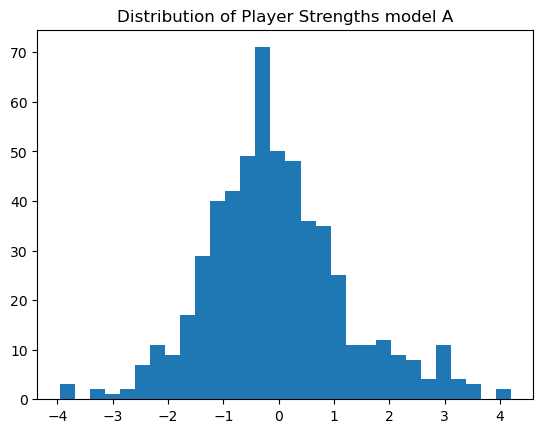

                player     alpha
472  Sasi Kumar Mukund  1.578866
158       Evan Furness  1.108138
259         Jelle Sels  0.790459
168       Facundo Mena  0.736782
196  Gerard Granollers  0.698419
522      Ulises Blanch  0.693085
38    Altug Celikbilek  0.656876
270       Johan Nikles  0.651000
236        Ivan Gakhov  0.646453
260    Jenson Brooksby  0.631997
                    player     alpha
138          Dominic Thiem -0.657003
382           Milos Raonic -0.663569
30        Alexander Zverev -0.673416
292          Kei Nishikori -0.691322
335            Marin Cilic -0.713485
283  Juan Martin Del Potro -0.777359
56             Andy Murray -0.783184
457          Roger Federer -0.873246
407         Novak Djokovic -0.947800
438           Rafael Nadal -0.981016


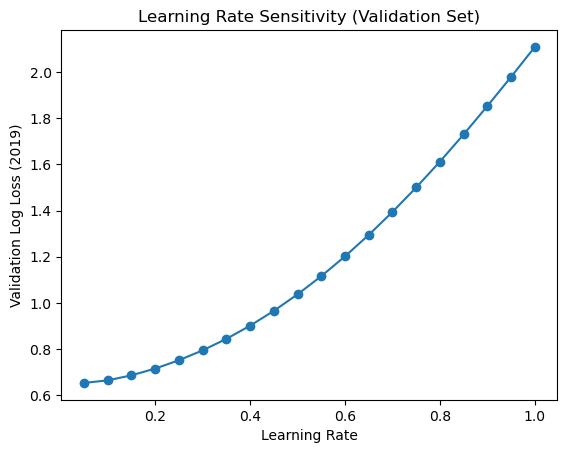

In [134]:
import matplotlib.pyplot as plt

plt.hist(alphas_fit, bins=30)
plt.title("Distribution of Player Strengths model A")
plt.show()

print(ranking.head(10))
print(ranking.tail(10))

import matplotlib.pyplot as plt

plt.plot(val_results_df['lr'], val_results_df['log_loss'], marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Validation Log Loss (2019)")
plt.title("Learning Rate Sensitivity (Validation Set)")
plt.show()

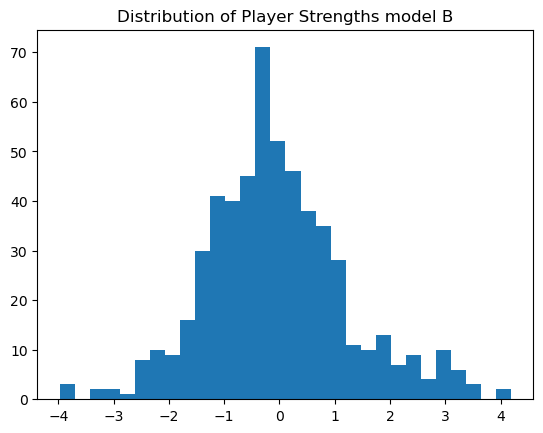

                    player     alpha
438           Rafael Nadal -3.968138
407         Novak Djokovic -3.936967
457          Roger Federer -3.843396
283  Juan Martin Del Potro -3.244952
56             Andy Murray -3.172480
292          Kei Nishikori -2.932194
30        Alexander Zverev -2.880878
335            Marin Cilic -2.656694
382           Milos Raonic -2.605081
138          Dominic Thiem -2.579462
                player     alpha
339    Markus Eriksson  3.139984
196  Gerard Granollers  3.172473
279       Jose Statham  3.200418
449          Rigele Te  3.257952
374     Michal Konecny  3.262643
522      Ulises Blanch  3.486411
169         Fajing Sun  3.488361
99           Cem Ilkel  3.573359
198  Gian Marco Moroni  3.941319
161  Evgeny Karlovskiy  4.188053


In [135]:
import matplotlib.pyplot as plt

plt.hist(alphas_B, bins=30)
plt.title("Distribution of Player Strengths model B")
plt.show()

ranking = pd.DataFrame({
    'player': players_fit,
    'alpha': alphas_B
}).sort_values('alpha', ascending=True)

print(ranking.head(10))
print(ranking.tail(10))

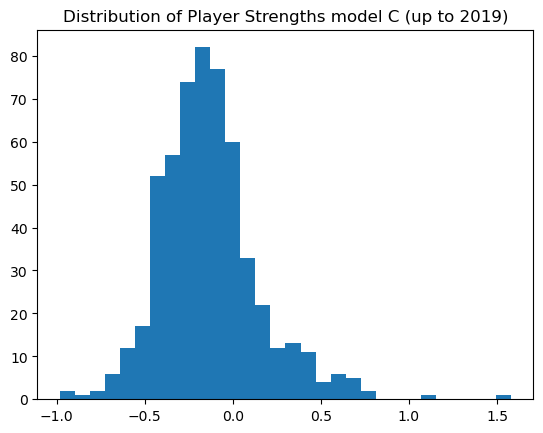

                    player     alpha
438           Rafael Nadal -3.968138
407         Novak Djokovic -3.936967
457          Roger Federer -3.843396
283  Juan Martin Del Potro -3.244952
56             Andy Murray -3.172480
292          Kei Nishikori -2.932194
30        Alexander Zverev -2.880878
335            Marin Cilic -2.656694
382           Milos Raonic -2.605081
138          Dominic Thiem -2.579462
                player     alpha
339    Markus Eriksson  3.139984
196  Gerard Granollers  3.172473
279       Jose Statham  3.200418
449          Rigele Te  3.257952
374     Michal Konecny  3.262643
522      Ulises Blanch  3.486411
169         Fajing Sun  3.488361
99           Cem Ilkel  3.573359
198  Gian Marco Moroni  3.941319
161  Evgeny Karlovskiy  4.188053


In [138]:
import matplotlib.pyplot as plt
plt.hist(alphas_C, bins=30)
plt.title("Distribution of Player Strengths model C (up to 2019)")
plt.show()

ranking_C = pd.DataFrame({
    'player': players_fit,
    'alpha': alphas_C
}).sort_values('alpha', ascending=True)

print(ranking.head(10))
print(ranking.tail(10))

In [185]:
_, _, preds_C= backtest_model_C(
    test_df=test_df,
    initial_alphas=alphas_after_2019_C,
    player_list=players_train,
    beta = beta_val_C,
    learning_rate=best_lr_C
)

_, _, preds_B= backtest_model_B(
    test_df=test_df,
    initial_alphas=alphas_after_2019_B,
    player_list=players_train,
    beta = beta_val_B,
    learning_rate=best_lr_B
)

_, _, preds_A= backtest_model(
    test_df=test_df,
    initial_alphas=alphas_after_2019,
    player_list=players_train,
    learning_rate=best_lr
)

y_true = test_df['is_participant1_winner'].values

In [205]:
import numpy as np

def expected_calibration_error(y_true, preds, n_bins=10):
    preds = np.clip(preds, 1e-12, 1 - 1e-12)
    
    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(preds, bins) - 1

    ece = 0.0
    n = len(preds)

    for i in range(n_bins):
        mask = bin_ids == i
        if np.sum(mask) == 0:
            continue

        acc = np.mean(y_true[mask])
        conf = np.mean(preds[mask])
        weight = np.sum(mask) / n

        ece += weight * abs(acc - conf)

    return ece

In [207]:
y_true = test_df['is_participant1_winner'].values

ece_A = expected_calibration_error(y_true, preds_A)
ece_B = expected_calibration_error(y_true, preds_B)
ece_C = expected_calibration_error(y_true, preds_C)
ece_market = expected_calibration_error(y_true, test_df['p1_market_norm'].values)

print("ECE A:", ece_A)
print("ECE B:", ece_B)
print("ECE C:", ece_C)
print("ECE Market:", ece_market)

ECE A: 0.18713928937110094
ECE B: 0.18588895005466813
ECE C: 0.1355277365771472
ECE Market: 0.008677951187584215


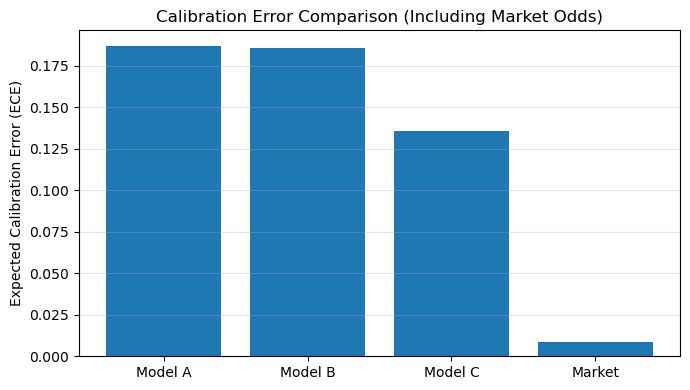

In [209]:
import matplotlib.pyplot as plt

models = ["Model A", "Model B", "Model C", "Market"]
ece_values = [ece_A, ece_B, ece_C, ece_market]

plt.figure(figsize=(7, 4))
plt.bar(models, ece_values)

plt.ylabel("Expected Calibration Error (ECE)")
plt.title("Calibration Error Comparison (Including Market Odds)")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()